# MLP Model Evaluation
Loads the trained MLP model and compares its predictions against the ground truth labels from `labeled_features.csv`.

In [1]:
import sys
from pathlib import Path

# Works whether run from project root or notebook directory
ROOT = Path().resolve()
if not (ROOT / 'models').exists():
    ROOT = ROOT.parents[2]

sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay,
)

DATA_PATH   = ROOT / 'data' / 'labeled_features.csv'
MODEL_PATH  = ROOT / 'models' / 'MLP' / 'mlp_model.pkl'
SCALER_PATH = ROOT / 'models' / 'MLP' / 'scaler.pkl'

FEATURE_COLS = [
    'ear_left', 'ear_right', 'ear_avg',
    'mar', 'pitch', 'yaw', 'roll',
    'perclos', 'blink_rate',
]
LABEL_NAMES = {0: 'ATTENTIVE', 1: 'SLEEPY', 2: 'DISTRACTED'}
COLORS = {'ATTENTIVE': '#2ecc71', 'SLEEPY': '#e67e22', 'DISTRACTED': '#e74c3c'}

print(f'ROOT       : {ROOT}')
print(f'Data       : {DATA_PATH.exists()}')
print(f'Model      : {MODEL_PATH.exists()}')
print(f'Scaler     : {SCALER_PATH.exists()}')

ROOT       : E:\Year 3 Sem 2\COS40007 Artificial Intelligence for Engineering\Design-Project\Campus_Concentration_Monitoring_System
Data       : True
Model      : True
Scaler     : True


## 1. Load Model and Dataset

In [2]:
mlp    = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

df = pd.read_csv(DATA_PATH)
df['label_name'] = df['label'].map(LABEL_NAMES)

print(f'Model      : {mlp}')
print(f'Samples    : {len(df)}')
print()
print('Ground truth distribution:')
print(df['label_name'].value_counts().to_string())

Model      : MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
Samples    : 2256

Ground truth distribution:
label_name
DISTRACTED    752
ATTENTIVE     752
SLEEPY        752


## 2. Run Predictions on Full Dataset

In [3]:
X = df[FEATURE_COLS].values.astype('float32')
X_scaled = scaler.transform(X)

y_true  = df['label'].values.astype(int)
y_pred  = mlp.predict(X_scaled)
y_proba = mlp.predict_proba(X_scaled)

df['predicted']      = y_pred
df['predicted_name'] = pd.Series(y_pred).map(LABEL_NAMES).values
df['correct']        = (y_true == y_pred)
df['confidence']     = y_proba.max(axis=1).round(4)

for i, name in LABEL_NAMES.items():
    df[f'prob_{name.lower()}'] = y_proba[:, i].round(4)

print(f'Overall accuracy: {accuracy_score(y_true, y_pred):.4f} ({accuracy_score(y_true, y_pred)*100:.2f}%)')
print(f'Correct         : {df["correct"].sum()} / {len(df)}')
print(f'Incorrect       : {(~df["correct"]).sum()} / {len(df)}')

Overall accuracy: 0.8338 (83.38%)
Correct         : 1881 / 2256
Incorrect       : 375 / 2256


## 3. Ground Truth vs Predicted — Side-by-Side

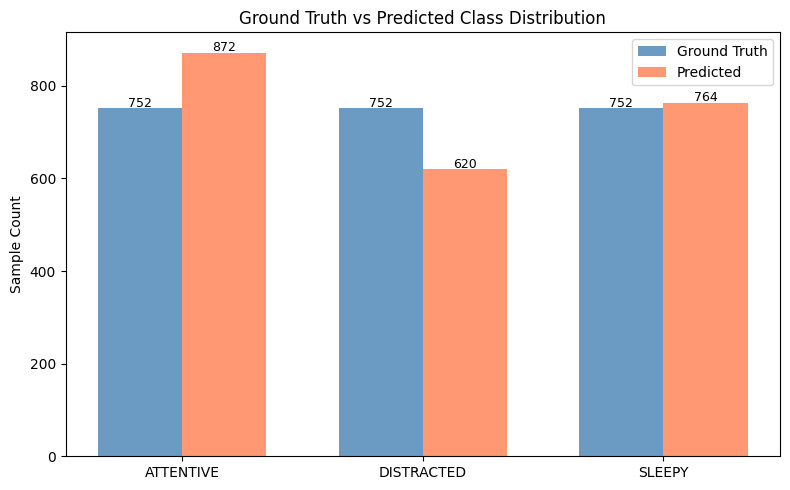

In [4]:
gt_counts   = df['label_name'].value_counts().sort_index()
pred_counts = df['predicted_name'].value_counts().sort_index()

classes = sorted(LABEL_NAMES.values())
x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, [gt_counts.get(c, 0) for c in classes],
               width, label='Ground Truth', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, [pred_counts.get(c, 0) for c in classes],
               width, label='Predicted', color='coral', alpha=0.8)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(int(bar.get_height())), ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel('Sample Count')
ax.set_title('Ground Truth vs Predicted Class Distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Classification Report

In [5]:
report = classification_report(y_true, y_pred, target_names=list(LABEL_NAMES.values()))
print('Classification Report')
print('=' * 55)
print(report)

Classification Report
              precision    recall  f1-score   support

   ATTENTIVE       0.75      0.87      0.80       752
      SLEEPY       0.90      0.92      0.91       752
  DISTRACTED       0.87      0.72      0.78       752

    accuracy                           0.83      2256
   macro avg       0.84      0.83      0.83      2256
weighted avg       0.84      0.83      0.83      2256



## 5. Confusion Matrices

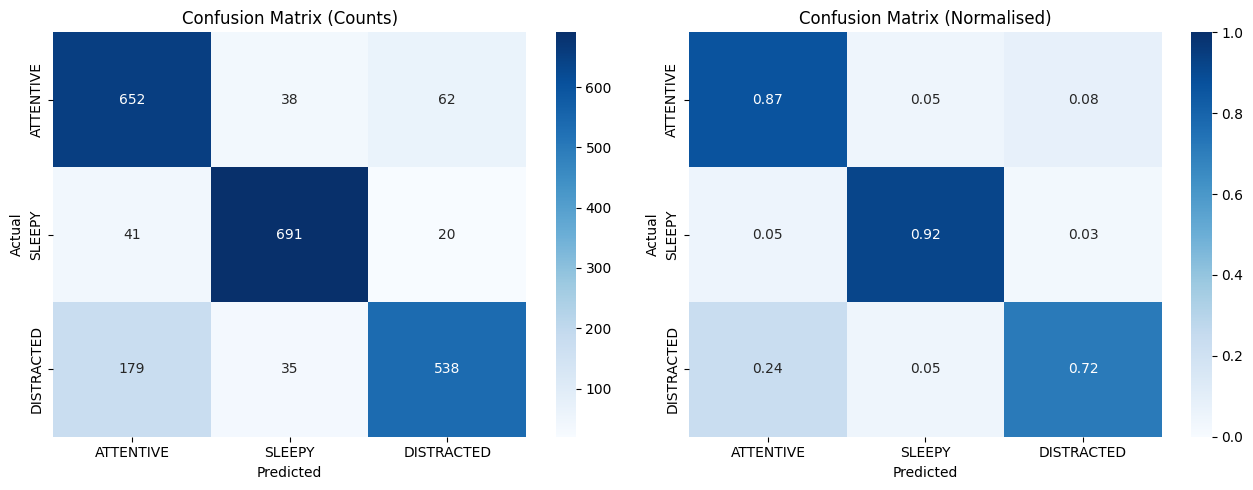

In [6]:
label_list = list(LABEL_NAMES.values())
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_list, yticklabels=label_list, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=label_list, yticklabels=label_list,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 6. Per-Class Accuracy

     Class  Total  Correct  Wrong  Accuracy
 ATTENTIVE    752      652    100  0.867021
    SLEEPY    752      691     61  0.918883
DISTRACTED    752      538    214  0.715426



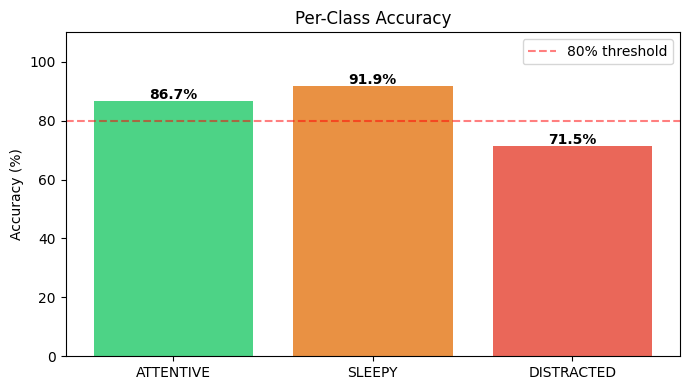

In [7]:
per_class = []
for lbl, name in LABEL_NAMES.items():
    mask = y_true == lbl
    total   = mask.sum()
    correct = ((y_pred == lbl) & mask).sum()
    per_class.append({'Class': name, 'Total': total,
                      'Correct': correct, 'Wrong': total - correct,
                      'Accuracy': correct / total if total > 0 else 0})

pc_df = pd.DataFrame(per_class)
print(pc_df.to_string(index=False))
print()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(pc_df['Class'], pc_df['Accuracy'] * 100,
              color=[COLORS[c] for c in pc_df['Class']], alpha=0.85)
for bar, val in zip(bars, pc_df['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}%', ha='center', fontweight='bold')
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy')
ax.axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Confidence Distribution (Correct vs Incorrect)

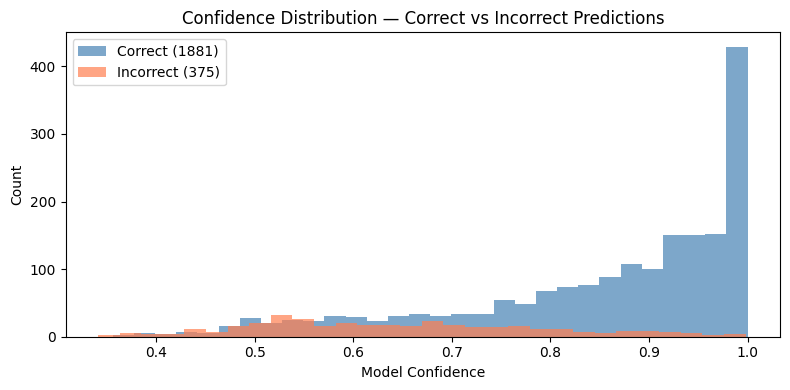

Avg confidence (correct)  : 0.853
Avg confidence (incorrect): 0.648


In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
correct_conf   = df[df['correct']]['confidence']
incorrect_conf = df[~df['correct']]['confidence']

ax.hist(correct_conf,   bins=30, alpha=0.7, color='steelblue', label=f'Correct ({len(correct_conf)})')
ax.hist(incorrect_conf, bins=30, alpha=0.7, color='coral',     label=f'Incorrect ({len(incorrect_conf)})')
ax.set_xlabel('Model Confidence')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution — Correct vs Incorrect Predictions')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Avg confidence (correct)  : {correct_conf.mean():.3f}')
print(f'Avg confidence (incorrect): {incorrect_conf.mean():.3f}')

## 8. Misclassification Analysis

In [9]:
wrong = df[~df['correct']].copy()
print(f'Total misclassified: {len(wrong)}\n')
print('Misclassification breakdown (Actual → Predicted):')
breakdown = wrong.groupby(['label_name', 'predicted_name']).size().reset_index(name='count')
breakdown = breakdown.sort_values('count', ascending=False)
print(breakdown.to_string(index=False))

Total misclassified: 375

Misclassification breakdown (Actual → Predicted):
label_name predicted_name  count
DISTRACTED      ATTENTIVE    179
 ATTENTIVE     DISTRACTED     62
    SLEEPY      ATTENTIVE     41
 ATTENTIVE         SLEEPY     38
DISTRACTED         SLEEPY     35
    SLEEPY     DISTRACTED     20


## 9. Sample-by-Sample View — Misclassified Rows

In [10]:
display_cols = ['label_name', 'predicted_name', 'confidence',
                'ear_avg', 'mar', 'pitch', 'yaw', 'perclos']

print('Worst misclassified (lowest confidence on wrong prediction):')
worse = wrong.sort_values('confidence', ascending=False)[display_cols].head(20)
worse.columns = ['Actual', 'Predicted', 'Conf', 'EAR', 'MAR', 'Pitch', 'Yaw', 'PERCLOS']
worse

Worst misclassified (lowest confidence on wrong prediction):


,Actual,Predicted,Conf,EAR,MAR,Pitch,Yaw,PERCLOS
805,ATTENTIVE,DISTRACTED,0.9981,0.2969,0.1227,-7.9704,50.7291,0.0
481,ATTENTIVE,SLEEPY,0.9965,0.1137,0.4739,20.5983,21.9976,1.0
1563,SLEEPY,DISTRACTED,0.9824,0.2149,0.0638,-5.2752,38.1745,1.0
1646,ATTENTIVE,DISTRACTED,0.9789,0.3078,0.0464,-9.1501,-44.2987,0.0
813,ATTENTIVE,DISTRACTED,0.9735,0.3825,0.0767,11.7176,-50.0569,0.0
1463,DISTRACTED,SLEEPY,0.9692,0.0974,0.0584,-6.5870,1.9441,1.0
2084,ATTENTIVE,SLEEPY,0.9624,0.2051,0.0045,11.5946,3.0140,1.0
1969,DISTRACTED,ATTENTIVE,0.9512,0.3798,0.0085,34.2639,-3.2801,0.0
34,ATTENTIVE,DISTRACTED,0.9488,0.4247,0.0186,-4.2279,40.6345,0.0
895,ATTENTIVE,DISTRACTED,0.9454,0.4447,0.0938,11.0235,-51.2871,0.0


## 10. Feature Means — Correct vs Incorrect Predictions

Feature means — correct vs incorrect predictions:
            Correct  Incorrect
ear_avg      0.2522     0.2433
mar          0.0805     0.0417
pitch        5.3285     8.0435
yaw         -3.8833    -0.0391
perclos      0.4083     0.4213
blink_rate   0.0000     0.0000



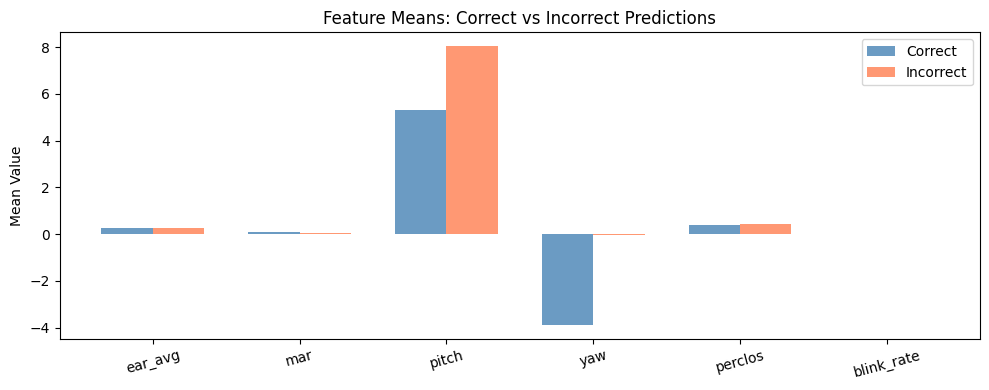

In [11]:
key_feats = ['ear_avg', 'mar', 'pitch', 'yaw', 'perclos', 'blink_rate']

correct_means   = df[df['correct']][key_feats].mean()
incorrect_means = df[~df['correct']][key_feats].mean()

comp = pd.DataFrame({'Correct': correct_means, 'Incorrect': incorrect_means})
print('Feature means — correct vs incorrect predictions:')
print(comp.round(4).to_string())
print()

x = np.arange(len(key_feats))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width/2, correct_means.values,   width, label='Correct',   color='steelblue', alpha=0.8)
ax.bar(x + width/2, incorrect_means.values, width, label='Incorrect', color='coral',     alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(key_feats, rotation=15)
ax.set_ylabel('Mean Value')
ax.set_title('Feature Means: Correct vs Incorrect Predictions')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Summary

In [12]:
acc = accuracy_score(y_true, y_pred)
print('=' * 45)
print('MODEL EVALUATION SUMMARY')
print('=' * 45)
print(f'Total samples     : {len(df)}')
print(f'Correct           : {df["correct"].sum()}')
print(f'Incorrect         : {(~df["correct"]).sum()}')
print(f'Overall accuracy  : {acc*100:.2f}%')
print()
for lbl, name in LABEL_NAMES.items():
    mask  = y_true == lbl
    acc_c = ((y_pred == lbl) & mask).sum() / mask.sum()
    print(f'  {name:<12}: {acc_c*100:.2f}%')
print('=' * 45)

MODEL EVALUATION SUMMARY
Total samples     : 2256
Correct           : 1881
Incorrect         : 375
Overall accuracy  : 83.38%

  ATTENTIVE   : 86.70%
  SLEEPY      : 91.89%
  DISTRACTED  : 71.54%


## 12. Dataset Image Samples — Ground Truth vs Predicted

Picks random images directly from the dataset folders, runs MediaPipe face detection + feature extraction + MLP, then displays each image annotated with its **ground truth** and **predicted** label.

- **Green border** = correct prediction  
- **Red border** = incorrect prediction

In [13]:
import random
import cv2
import urllib.request
import mediapipe as mp
from mediapipe.tasks.python import BaseOptions
from mediapipe.tasks.python.vision import FaceLandmarker, FaceLandmarkerOptions
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode
from src.classifiers.landmark_pipeline.feature_extractor import FeatureExtractor, FEATURE_COLS as _FCOLS

# ── MediaPipe setup ───────────────────────────────────────────────────────────
_TASK = ROOT / 'src' / 'classifiers' / 'landmark_pipeline' / 'face_landmarker.task'
if not _TASK.exists():
    _TASK = ROOT / 'face_landmarker.task'
if not _TASK.exists():
    _URL = ('https://storage.googleapis.com/mediapipe-models/'
            'face_landmarker/face_landmarker/float16/1/face_landmarker.task')
    print('Downloading face_landmarker.task ...')
    urllib.request.urlretrieve(_URL, str(_TASK))

_landmarker = FaceLandmarker.create_from_options(
    FaceLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=str(_TASK)),
        running_mode=VisionTaskRunningMode.IMAGE,
        num_faces=1,
    )
)

def _get_features(img_bgr):
    """Run MediaPipe + FeatureExtractor on one image. Returns features dict or None."""
    h, w = img_bgr.shape[:2]
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    result = _landmarker.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb))
    if not result.face_landmarks:
        return None
    face = result.face_landmarks[0]
    lm = [(lm.x * w, lm.y * h, lm.z) for lm in face]
    fe = FeatureExtractor(frame_w=w, frame_h=h)
    return fe.extract(lm)

def _predict_image(img_bgr):
    """Returns (label_id, confidence) or (None, None) if no face detected."""
    feats = _get_features(img_bgr)
    if feats is None:
        return None, None
    X = np.array([[feats[c] for c in _FCOLS]], dtype='float32')
    X_s = scaler.transform(X)
    pred  = int(mlp.predict(X_s)[0])
    conf  = float(mlp.predict_proba(X_s).max())
    return pred, conf

# ── Image sources ─────────────────────────────────────────────────────────────
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

# Folder-per-class sources
FOLDER_SOURCES = [
    # Kaggle drowsy dataset
    (ROOT / 'src' / 'classifiers' / 'landmark_pipeline' / 'data' / 'kaggle_drowsy', {
        'active subjects':  0,
        'fatigue subjects': 1,
        'yawning subjects': 1,
    }),
    (ROOT / 'data' / 'kaggle_drowsy', {
        'active subjects':  0,
        'fatigue subjects': 1,
        'yawning subjects': 1,
    }),
    # Roboflow distracted (classification format: train/ClassName/)
    (ROOT / 'data' / 'roboflow_distracted', {
        'distracted':     2,
        'non-distracted': 0,
    }),
]

def _collect_folder_samples(n_per_class=6):
    """Scan folder-per-class datasets and return {label_id: [(img_bgr, path), ...]}."""
    pool = {0: [], 1: [], 2: []}
    for base, label_map in FOLDER_SOURCES:
        if not base.exists():
            continue
        for d in base.rglob('*'):
            if not d.is_dir():
                continue
            key = d.name.lower()
            if key not in label_map:
                continue
            lbl = label_map[key]
            imgs = [p for p in d.glob('*') if p.suffix.lower() in IMG_EXTS]
            random.shuffle(imgs)
            for p in imgs:
                if len(pool[lbl]) >= n_per_class * 3:
                    break
                img = cv2.imread(str(p))
                if img is not None:
                    pool[lbl].append((img, p))
    return pool

print('MediaPipe ready.')

MediaPipe ready.


  ATTENTIVE: 60 candidates found
  SLEEPY: 60 candidates found
  DISTRACTED: 60 candidates found

Running predictions (this may take ~30 seconds) ...


c:\Users\benji\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
c:\Users\benji\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
c:\Users\benji\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabas

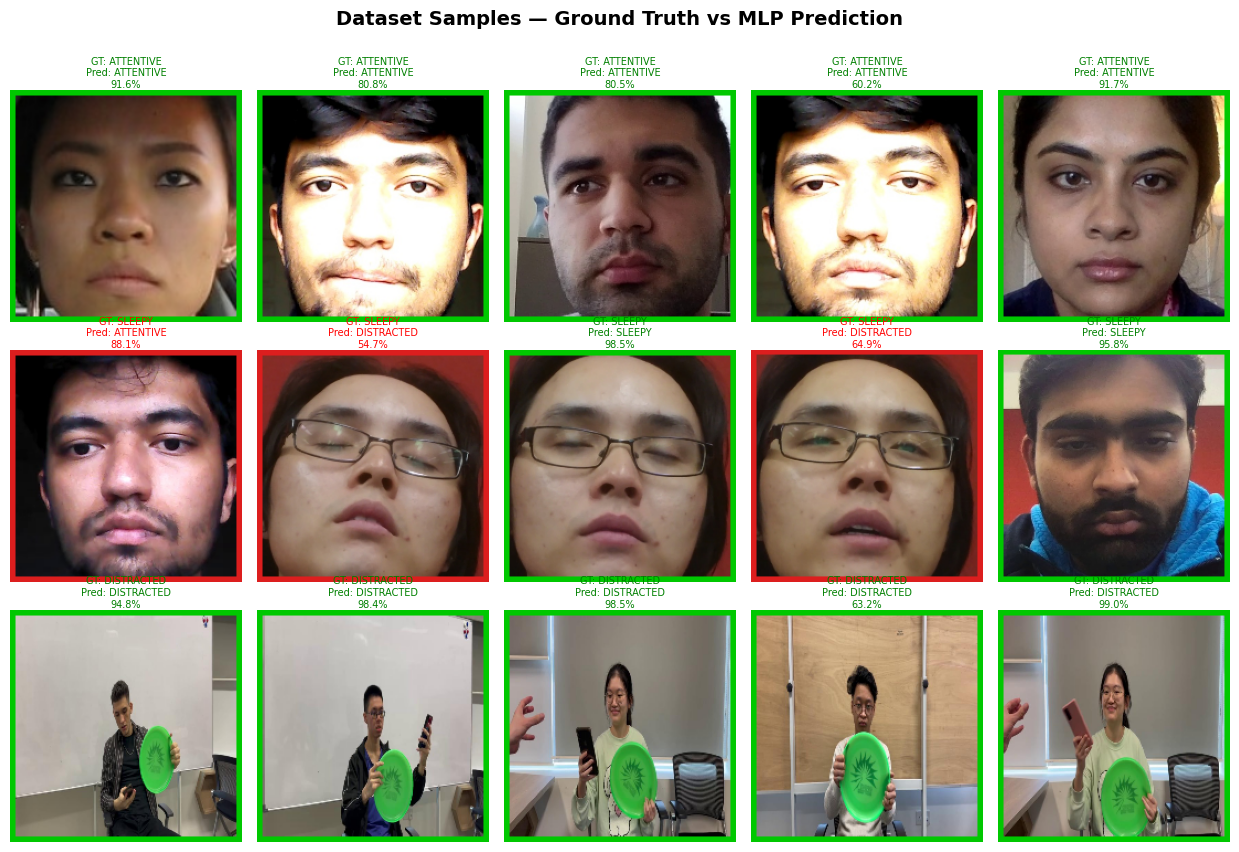

In [14]:
def _annotate(img_bgr, gt_name, pred_name, conf, correct):
    """Resize image and draw colored border + text labels."""
    img = cv2.resize(img_bgr, (200, 200))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    border_color = (0, 180, 0) if correct else (220, 0, 0)   # green / red (RGB)
    img_rgb = cv2.copyMakeBorder(img_rgb, 4, 4, 4, 4,
                                 cv2.BORDER_CONSTANT, value=border_color)
    return img_rgb, gt_name, pred_name, conf

def show_sample_grid(title, samples_by_class, n_per_class=5):
    """
    samples_by_class: {label_id: [(img_bgr, path), ...]}
    Runs prediction on each image and plots a grid: rows = classes, cols = samples.
    """
    BORDER = {'correct': (0, 200, 0), 'wrong': (220, 30, 30)}
    n_classes = len(LABEL_NAMES)
    fig, axes = plt.subplots(n_classes, n_per_class,
                             figsize=(n_per_class * 2.5, n_classes * 2.8))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    for row, (lbl_id, lbl_name) in enumerate(LABEL_NAMES.items()):
        candidates = samples_by_class.get(lbl_id, [])
        random.shuffle(candidates)
        col = 0
        for img_bgr, path in candidates:
            if col >= n_per_class:
                break
            pred_id, conf = _predict_image(img_bgr)
            if pred_id is None:
                continue   # no face detected — skip
            pred_name = LABEL_NAMES[pred_id]
            correct   = (pred_id == lbl_id)

            img = cv2.resize(img_bgr, (200, 200))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            border = BORDER['correct'] if correct else BORDER['wrong']
            img_rgb = cv2.copyMakeBorder(img_rgb, 5, 5, 5, 5,
                                         cv2.BORDER_CONSTANT, value=border)

            ax = axes[row][col] if n_classes > 1 else axes[col]
            ax.imshow(img_rgb)
            ax.axis('off')
            color = 'green' if correct else 'red'
            ax.set_title(
                f'GT: {lbl_name}\nPred: {pred_name}\n{conf*100:.1f}%',
                fontsize=7, color=color, pad=2
            )
            col += 1

        # Fill empty slots if not enough faces detected
        while col < n_per_class:
            ax = axes[row][col] if n_classes > 1 else axes[col]
            ax.axis('off')
            col += 1

        # Row label on the left
        axes[row][0].set_ylabel(lbl_name, fontsize=9, fontweight='bold', rotation=90)

    plt.tight_layout()
    plt.show()

# ── Collect and display ───────────────────────────────────────────────────────
N_SAMPLES = 5   # images per class to show

print('Collecting sample images ...')
pool = _collect_folder_samples(n_per_class=N_SAMPLES * 4)
for lbl, name in LABEL_NAMES.items():
    print(f'  {name}: {len(pool[lbl])} candidates found')

print('\nRunning predictions (this may take ~30 seconds) ...')
show_sample_grid('Dataset Samples — Ground Truth vs MLP Prediction', pool, n_per_class=N_SAMPLES)